# 4 &middot; Adding a custom deterministic function to Discovery

In notebook 2 we fit a basic noise model to one pulsar.

We included:

* **timing model** &mdash; marginalised analytically (a GP over the design matrix $M$),
* **white noise** &mdash; per-backend `EFAC` (scales the TOA errors) and `EQUAD` (added in quadrature),
* **red noise** &mdash; an achromatic power-law Gaussian process (spin noise),
* **DM noise** &mdash; a chromatic ($\nu^{-2}$) power-law Gaussian process.

Now we will introduce our own additional model component, a deterministic function. In this case, we will introduce **annual dispersion measure variations** as a sinusoid in the timing resdiuals that scales in amplitude as frequency^-2

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import jax, jax.random
import discovery as ds
import discovery.signals as signals
import discovery.likelihood as likelihood
import discovery.prior as prior
import discovery.samplers.numpyro as ds_numpyro

DATADIR = "./my_feathers/"
psrname = "J0613-0200" # Let's try J0613... you'll see why!

psr = ds.Pulsar.read_feather(os.path.join(DATADIR, psrname + ".feather"))
print("Loaded", psr.name, "with", len(psr.toas), "TOAs")

Loaded J0613-0200 with 3067 TOAs


### How big should the Gaussian processes be?

A power-law GP is represented by a set of Fourier frequencies (sine/cosine pairs). We
choose how many from the data span and a maximum cadence: a longer cadence means
coarser time resolution and therefore **fewer** components &mdash; faster to sample.

In [2]:
max_cadence_days = 60
Tspan = signals.getspan(psr)
components = int(Tspan / (max_cadence_days * 86400.0))
print(f"Tspan = {Tspan/86400/365.25:.1f} yr -> {components} Fourier frequency components")

Tspan = 4.3 yr -> 26 Fourier frequency components


### Build the model

A Discovery model is just a **list of components** wrapped in a `PulsarLikelihood`.
The first element is the data (residuals); the rest are the signals.

In [3]:
model_components = []
model_components.append(psr.residuals)                                     # data
model_components.append(signals.makegp_timing(psr, svd=True))              # timing model (marginalised)
model_components.append(signals.makenoise_measurement(psr, tnequad=True))  # EFAC + EQUAD per backend

# Achromatic red (spin) noise, power-law Fourier GP
model_components.append(
    signals.makegp_fourier(psr, signals.powerlaw, components=components, name="red_noise"))

# DM noise: chromatic (freq^-2) power-law Fourier GP (freq^-2 basis)
model_components.append(
    signals.makegp_fourier(psr, signals.powerlaw, components=components,
                           fourierbasis=signals.dmfourierbasis, name="dm_gp"))


# Now let's define and add a deterministic function

See more examples in Daniel's version of Discovery: https://github.com/danielreardon/discovery/blob/main/src/discovery/deterministic.py

In [4]:
import jax.numpy as jnp

def dm_annual(psr, fref=1400.0):
    """DM annual delay model."""
    toas, fnorm = ds.matrix.jnparray(psr.toas), ds.matrix.jnparray(fref / psr.freqs)

    def delay(log10_Amp, phase):
        return 10**log10_Amp * jnp.sin(2*jnp.pi * ds.const.fyr * toas + phase) * fnorm**2

    return delay

model_components += [signals.makedelay(psr, dm_annual(psr), name='dm_annual')]

In [5]:
# Note we now have the dm annual model 
model = likelihood.PulsarLikelihood(model_components)

print("Free parameters in the model:")
for p in model.logL.params:
    print("   ", p)

Free parameters in the model:
    J0613-0200_KAT_MKBF_efac
    J0613-0200_KAT_MKBF_log10_tnequad
    J0613-0200_dm_annual_log10_Amp
    J0613-0200_dm_annual_phase
    J0613-0200_dm_gp_gamma
    J0613-0200_dm_gp_log10_A
    J0613-0200_red_noise_gamma
    J0613-0200_red_noise_log10_A


### Set the priors

Every free parameter gets a flat (uniform) prior. We set the ranges explicitly so
you can see exactly what is assumed.

In [6]:
prior.priordict_standard.update({
    r"(.*_)?efac":              [0.5, 2.0],
    r"(.*_)?log10_tnequad":     [-10, -5],
    r"(.*_)?red_noise_log10_A.*": [-18, -11],
    r"(.*_)?red_noise_gamma.*":   [0, 7],
    r"(.*_)?dm_gp_log10_A":     [-18, -11],
    r"(.*_)?dm_gp_gamma":       [0, 7],
    r"(.*_)?dm_annual_log10_Amp": [-10, -4],
    r"(.*_)?dm_annual_phase": [0, 2 * np.pi],
})
for p in model.logL.params:
    print(f"   {p:40s} {prior.getprior_uniform(p, {})}")

   J0613-0200_KAT_MKBF_efac                 [0.5, 2.0]
   J0613-0200_KAT_MKBF_log10_tnequad        [-8.5, -5]
   J0613-0200_dm_annual_log10_Amp           [-10, -4]
   J0613-0200_dm_annual_phase               [0, 6.283185307179586]
   J0613-0200_dm_gp_gamma                   [0, 7]
   J0613-0200_dm_gp_log10_A                 [-18, -11]
   J0613-0200_red_noise_gamma               [0, 7]
   J0613-0200_red_noise_log10_A             [-18, -11]


### Sample the posterior with NUTS

`makemodel_transformed` reparametrizes the parameters to an unconstrained space for
efficient Hamiltonian sampling; NUTS then explores it. `num_warmup` tunes the
sampler; `num_samples` are the kept draws. A real analysis would use more &mdash; these
keep the workshop fast.

In [7]:
npmodel = ds_numpyro.makemodel_transformed(model.logL)
sampler = ds_numpyro.makesampler_nuts(npmodel, num_warmup=500, num_samples=1000)

key = jax.random.PRNGKey(123456789)     # fixed seed -> reproducible chain
sampler.run(key)                 # the part that takes a minute or two

sample: 100%|██████████| 1500/1500 [07:26<00:00,  3.36it/s, 63 steps of size 5.70e-02. acc. prob=0.93]


### Save the chain

`sampler.to_df()` returns the posterior as a pandas `DataFrame` with one column per
(physical) parameter. The sampler doesn't hand back the likelihood, so we evaluate
`model.logL` ourselves at every sample and store it as a
`logl` column &mdash; we'll need it for the maximum-likelihood point below. Then we pickle
the chain so we can reload it later without re-running the sampler.

In [8]:
chain = sampler.to_df()
chain = chain[[p for p in model.logL.params]].copy()      # keep just the model parameters
# evaluate the (marginalised) log-likelihood at every posterior sample
chain["logl"] = np.asarray(jax.lax.map(model.logL, {p: chain[p].values for p in model.logL.params}))

outdir = "./results"
os.makedirs(outdir, exist_ok=True)
save_base = os.path.join(outdir, psrname + "_annual")
chain.to_pickle(save_base + ".pickle")
print("saved", save_base + ".pickle", " shape:", chain.shape)
chain.head()

saved ./results/J0613-0200_annual.pickle  shape: (1000, 9)


,J0613-0200_KAT_MKBF_efac,J0613-0200_KAT_MKBF_log10_tnequad,J0613-0200_dm_annual_log10_Amp,J0613-0200_dm_annual_phase,J0613-0200_dm_gp_gamma,J0613-0200_dm_gp_log10_A,J0613-0200_red_noise_gamma,J0613-0200_red_noise_log10_A,logl
0,0.982874,-6.557170,-6.537473,2.850646,3.045459,-13.539428,2.351423,-17.397978,38713.524962
1,0.981079,-6.612133,-6.537510,2.901636,3.070030,-13.549495,3.022887,-16.794480,38712.596934
2,0.997208,-6.586493,-6.541132,2.943140,2.779942,-13.538179,6.065403,-15.046883,38714.239378
3,0.982038,-6.596264,-6.783042,2.988695,3.189699,-13.656889,5.739639,-14.509176,38710.235008
4,0.979214,-6.499321,-6.792017,2.748660,2.899286,-13.695616,5.629818,-15.268563,38709.878589


### Maximum-likelihood parameters

The "best fit" point estimate is the sample with the highest log-likelihood. We
also save it to JSON &mdash; later analyses (e.g. a common-noise / GWB search) read
these per-pulsar values as a fixed noise dictionary.

In [9]:
import json

ml_idx = chain["logl"].idxmax()
ml_params = chain.loc[ml_idx].to_dict()

with open(save_base + ".json", "w") as f:
    json.dump(ml_params, f, indent=2)

print("Maximum-likelihood parameters:")
for k, v in ml_params.items():
    if k == "logl":
        continue
    print(f"   {k:40s} = {v:+.3f}")


Maximum-likelihood parameters:
   J0613-0200_KAT_MKBF_efac                 = +0.997
   J0613-0200_KAT_MKBF_log10_tnequad        = -6.586
   J0613-0200_dm_annual_log10_Amp           = -6.541
   J0613-0200_dm_annual_phase               = +2.943
   J0613-0200_dm_gp_gamma                   = +2.780
   J0613-0200_dm_gp_log10_A                 = -13.538
   J0613-0200_red_noise_gamma               = +6.065
   J0613-0200_red_noise_log10_A             = -15.047


### Corner plot

A corner plot shows the 1-D marginal posterior of each parameter (the histograms
on the diagonal) and every 2-D joint posterior (the off-diagonal contours). It is
the standard way to read off measured values and spot correlations. We build it by
hand with the `corner` package.

/opt/build_psrsoft/workspace/micromamba/envs/IPTA_Env/lib/python3.11/site-packages/astropy/config/paths.py:55: AstropyUserWarning: XDG_CONFIG_HOME is set to '/home/pulsar/.config', but the default location, /home/pulsar/.astropy/config, already exists, and takes precedence. This environment variable will be ignored.
  return set_temp_config._get_dir_path(rootname)


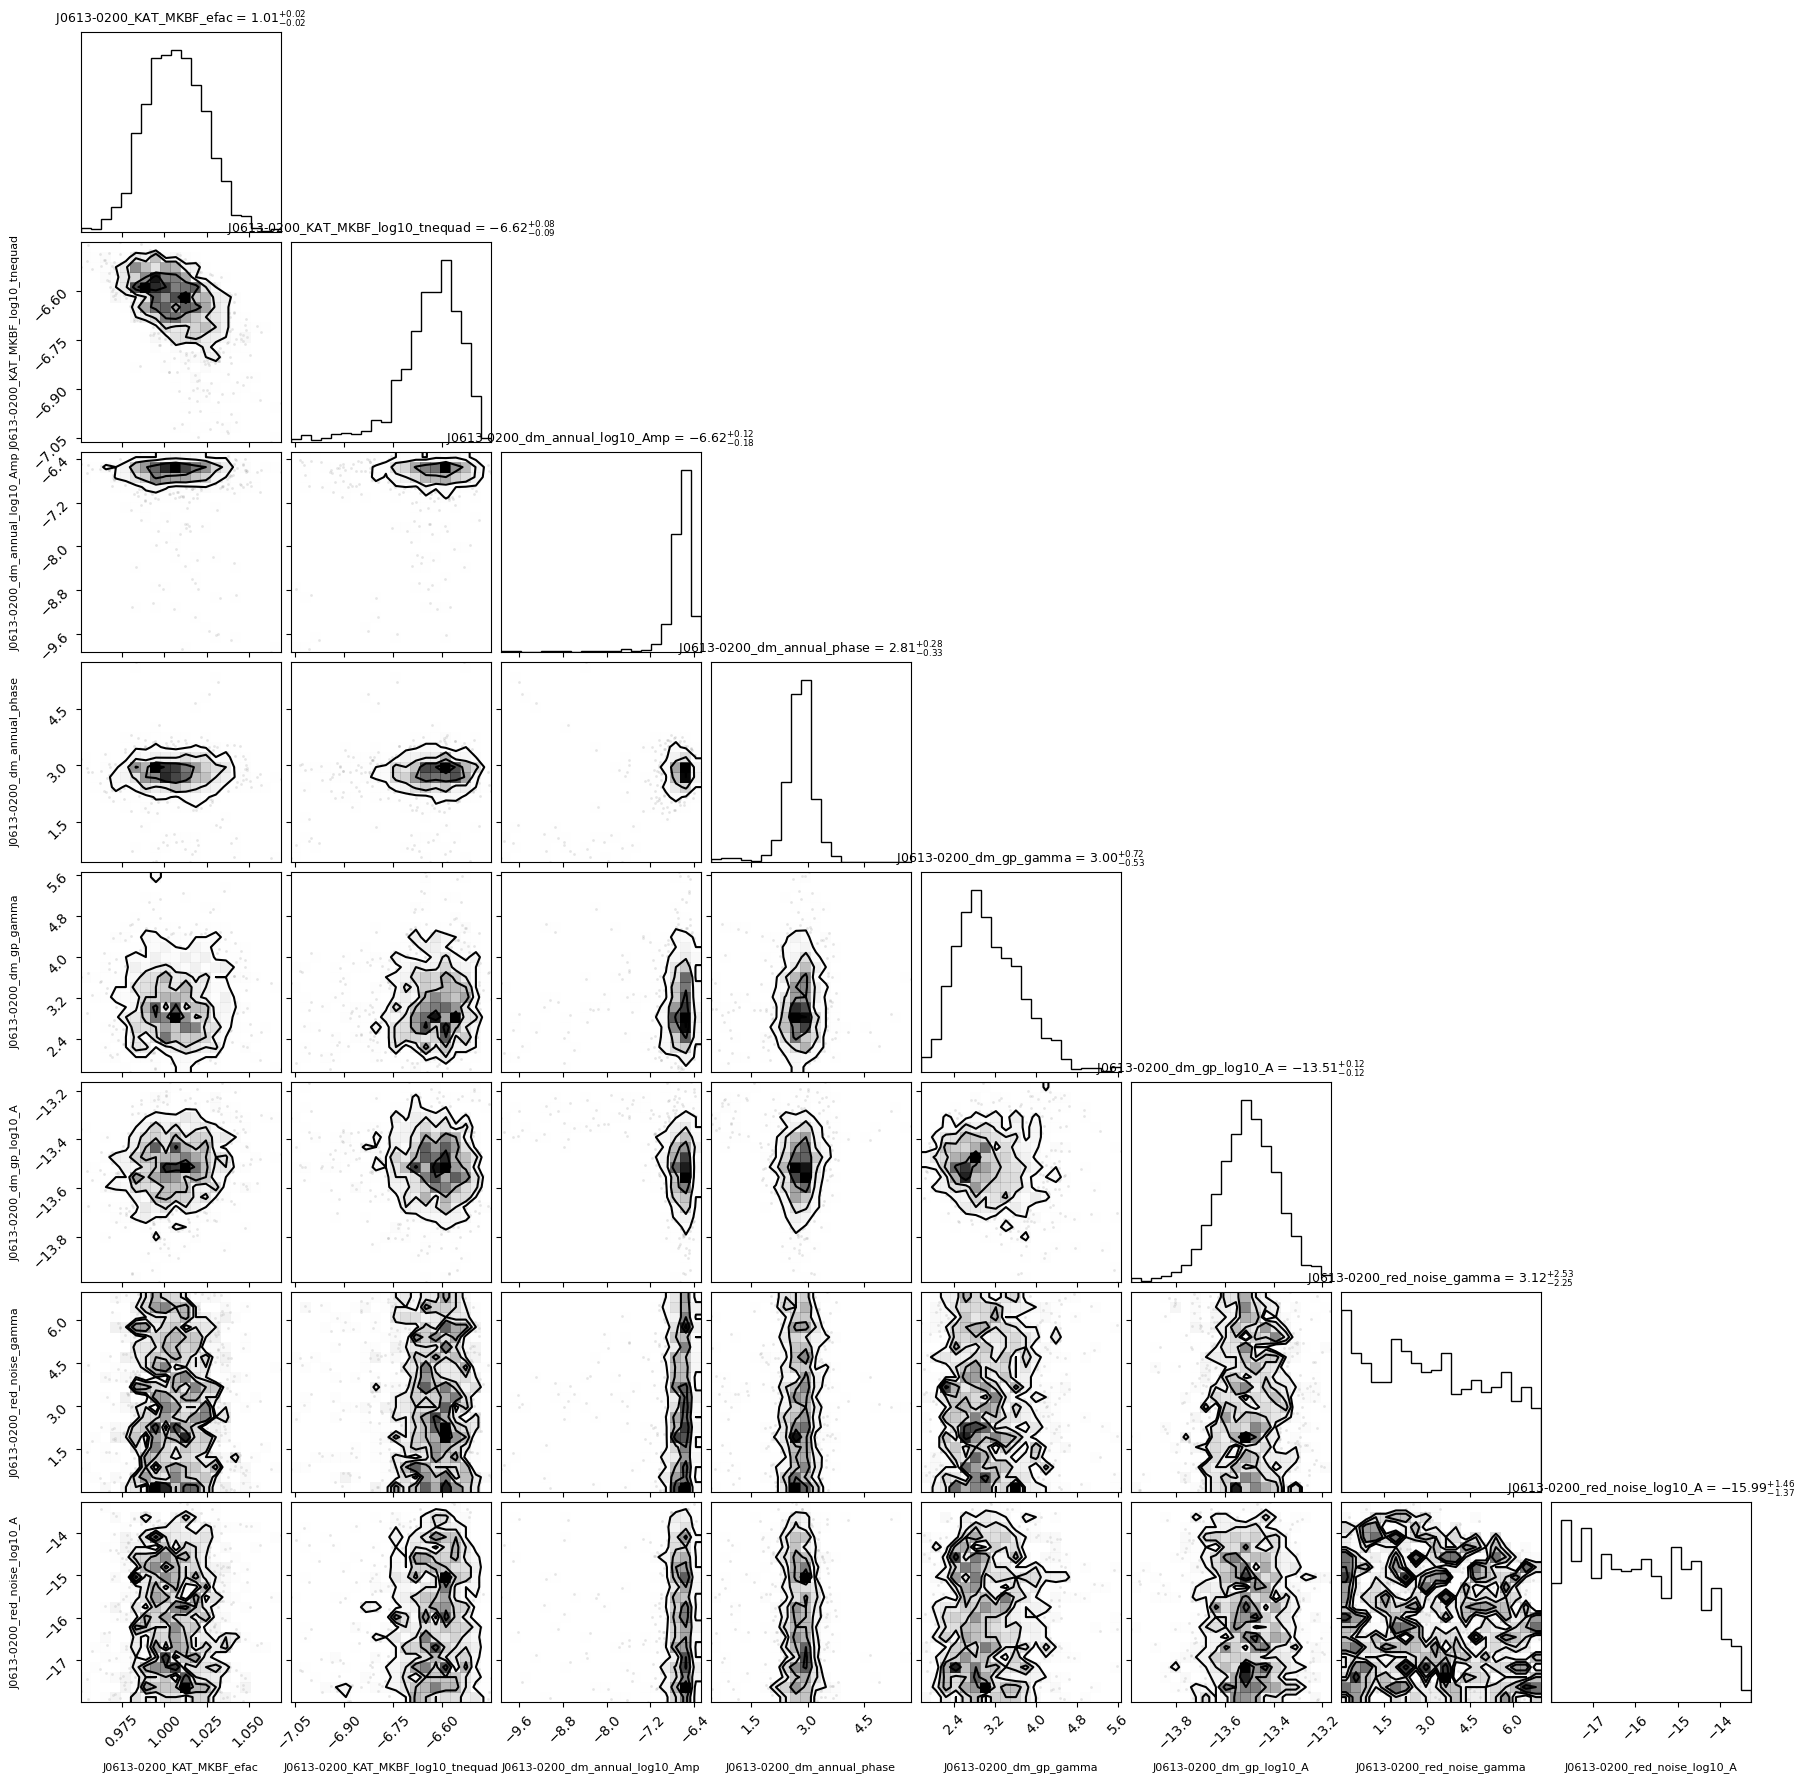

In [10]:
import corner

labels = [c for c in chain.columns if c != "logl"]
fig = corner.corner(
    chain[labels].values,
    labels=labels,
    show_titles=True,
    title_fmt=".2f",
    title_kwargs={"fontsize": 9},
    label_kwargs={"fontsize": 8},
)
fig.savefig(save_base + "_corner.png", dpi=120, bbox_inches="tight")
plt.show()

**How to read it**

* `red_noise_log10_A`, `red_noise_gamma` &mdash; amplitude and slope of the **spin noise**.
* `dm_gp_log10_A`, `dm_gp_gamma` &mdash; amplitude and slope of the **DM noise**.
* The `efac`/`log10_tnequad` columns are the per-backend **white-noise** parameters.

If a `log10_A` posterior is a clean peak well above the lower prior edge, that
process is **detected**. If instead it piles up against the lower edge of the
prior (an upper limit, no peak), the data don't require that process &mdash; it is
**not significant**. We explore exactly that in the next notebook.